In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [13]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.info()

Dataset Shape: (891, 12)

Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtyp

In [15]:
df_temp = df.fillna(0)

df_encoded = pd.get_dummies(df_temp, drop_first=True)

X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

acc_before = accuracy_score(y_test, pred)
precision_before = precision_score(y_test, pred)
recall_before = recall_score(y_test, pred)
f1_before = f1_score(y_test, pred)

print("Before Cleaning")
print("Accuracy:", acc_before)
print("Precision:", precision_before)
print("Recall:", recall_before)
print("F1 Score:", f1_before)

Before Cleaning
Accuracy: 0.659217877094972
Precision: 1.0
Recall: 0.17567567567567569
F1 Score: 0.2988505747126437


In [16]:
df_cleaned = df.copy()

for col in df_cleaned.columns:
    if col != 'Survived':
        if df_cleaned[col].dtype == 'object':
            df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])
        else:
            df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

In [17]:
df_cleaned_encoded = pd.get_dummies(df_cleaned, drop_first=True)

In [18]:
X2 = df_cleaned_encoded.drop('Survived', axis=1)
y2 = df_cleaned_encoded['Survived']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

model2.fit(X_train2, y_train2)

pred2 = model2.predict(X_test2)

acc_after = accuracy_score(y_test2, pred2)
precision_after = precision_score(y_test2, pred2)
recall_after = recall_score(y_test2, pred2)
f1_after = f1_score(y_test2, pred2)

print("After Cleaning")
print("Accuracy:", acc_after)
print("Precision:", precision_after)
print("Recall:", recall_after)
print("F1 Score:", f1_after)

After Cleaning
Accuracy: 0.7374301675977654
Precision: 0.9655172413793104
Recall: 0.3783783783783784
F1 Score: 0.5436893203883495


In [19]:
param_grid = {
    'n_estimators': [50,100,150],
    'max_depth': [5,10,15],
    'min_samples_split': [2,5]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train2, y_train2)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

pred3 = best_model.predict(X_test2)

acc_tuned = accuracy_score(y_test2, pred3)
precision_tuned = precision_score(y_test2, pred3)
recall_tuned = recall_score(y_test2, pred3)
f1_tuned = f1_score(y_test2, pred3)

print("After Hyperparameter Tuning")
print("Accuracy:", acc_tuned)
print("Precision:", precision_tuned)
print("Recall:", recall_tuned)
print("F1 Score:", f1_tuned)

Best Parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 100}
After Hyperparameter Tuning
Accuracy: 0.7653631284916201
Precision: 0.9210526315789473
Recall: 0.47297297297297297
F1 Score: 0.625


In [20]:
print("\nClassification Report:\n")
print(classification_report(y_test2, pred3))


Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.97      0.83       105
           1       0.92      0.47      0.62        74

    accuracy                           0.77       179
   macro avg       0.82      0.72      0.73       179
weighted avg       0.81      0.77      0.74       179



In [21]:
cm = confusion_matrix(y_test2, pred3)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[102   3]
 [ 39  35]]


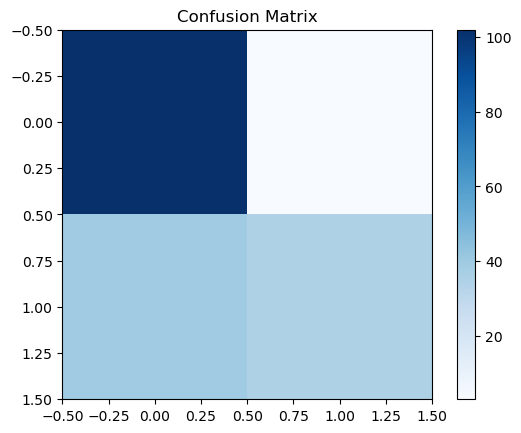

In [22]:
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [23]:
results = pd.DataFrame({
    "Stage": ["Before Cleaning","After Cleaning","After Hyperparameter Tuning"],
    "Accuracy": [acc_before, acc_after, acc_tuned],
    "Precision": [precision_before, precision_after, precision_tuned],
    "Recall": [recall_before, recall_after, recall_tuned],
    "F1 Score": [f1_before, f1_after, f1_tuned]
})

print(results)

                         Stage  Accuracy  Precision    Recall  F1 Score
0              Before Cleaning  0.659218   1.000000  0.175676  0.298851
1               After Cleaning  0.737430   0.965517  0.378378  0.543689
2  After Hyperparameter Tuning  0.765363   0.921053  0.472973  0.625000


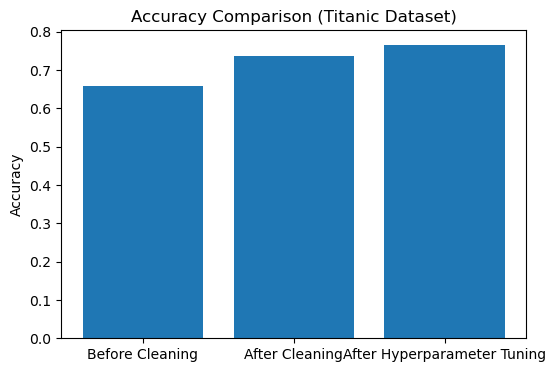

In [24]:
plt.figure(figsize=(6,4))

plt.bar(results["Stage"], results["Accuracy"])
plt.title("Accuracy Comparison (Titanic Dataset)")
plt.ylabel("Accuracy")

plt.show()

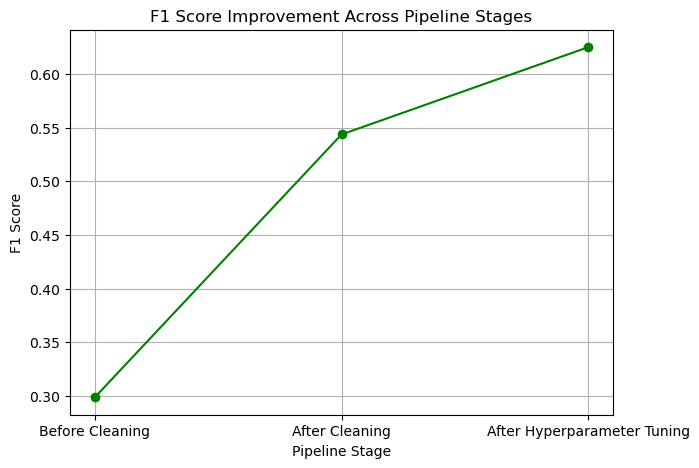

In [25]:
plt.figure(figsize=(7,5))

plt.plot(results["Stage"], results["F1 Score"], marker='o', color='green')
plt.title("F1 Score Improvement Across Pipeline Stages")
plt.xlabel("Pipeline Stage")
plt.ylabel("F1 Score")

plt.grid(True)
plt.show()

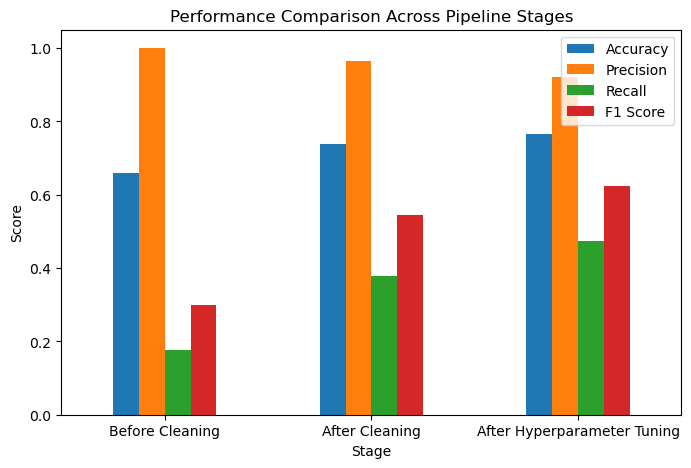

In [26]:
results.set_index("Stage").plot(kind="bar", figsize=(8,5))

plt.title("Performance Comparison Across Pipeline Stages")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()